# 학습 목표
- iceberg 아키텍처와 동작 흐름을 이해한다.
- PySpark SQL 을 이용해서 Iceberg 카탈로그, 테이블을 생성한다.
- PySpark SQL 을 이용해서 Iceberg 테이블 INSERT, UPDATE 해본다.

## 참고
- boto3 라이브러리가 없을 경우 `!python3 -m pip install boto3` 로 설치한다.
- fastavro 라이브러리가 없을 경우 `!python3 -m pip install fastavro` 로 설치한다.
- 학습 단계에서 사용하는 Iceberg 저장소: MinIO(S3 대체)
- 학습 단계에서 사용하는 Iceberg 카탈로그 서버: REST 카탈로그(sqlite 에 정보 기록)

---

In [10]:
# ! python3 -m pip install --upgrade pip
# ! python3 -m pip install boto3 fastavro

In [38]:
# 페이지에 필요한 라이브러리 선언
import io
import json
import boto3
from fastavro import reader as avro_reader
from IPython.display import Image
from utils.iceberg_metadata_properties import IcebergMetadataJsonField, FIELD_DESCRIPTIONS
from utils.get_iceberg_metadata import get_metadata

---

# Iceberg 아키텍처

📋 Icebert 아키텍처


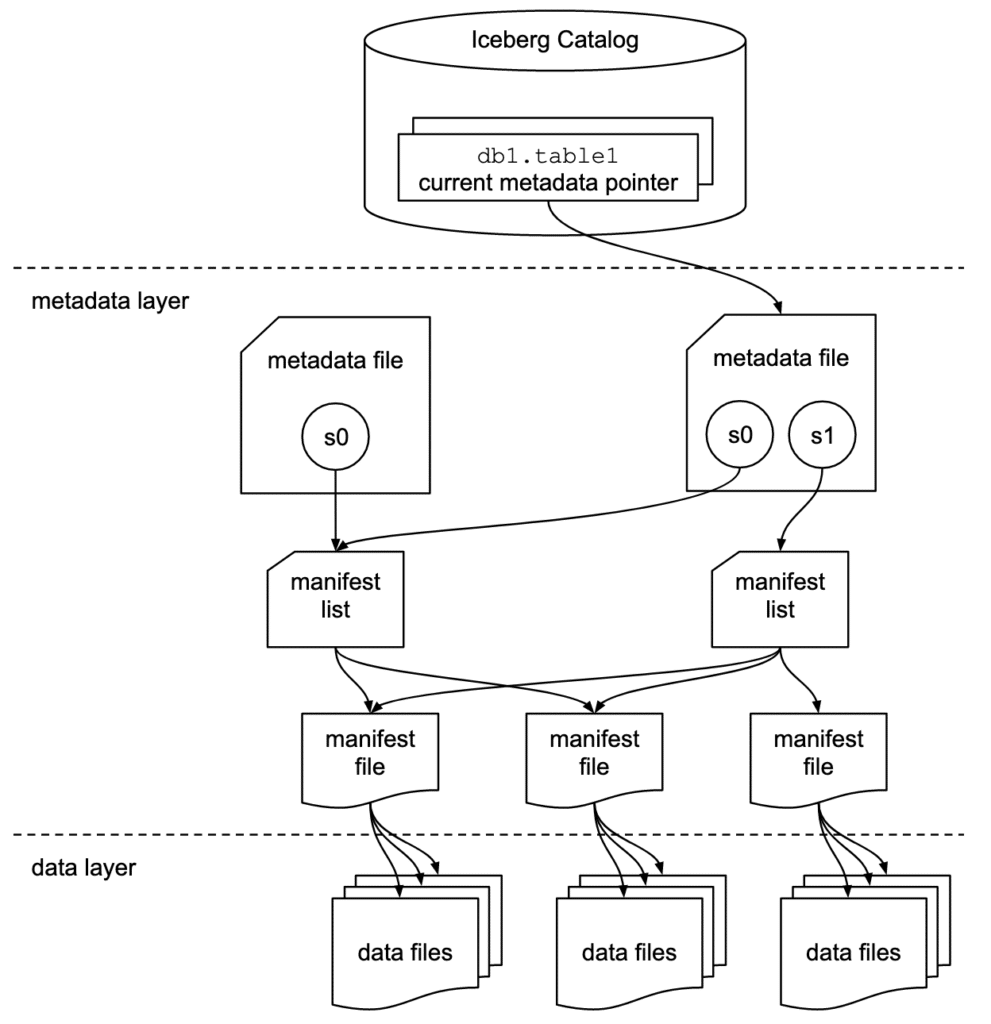

In [12]:
print("📋 Icebert 아키텍처")
Image("/home/iceberg/notebooks/images/iceberg_architecture.png")

> Iceberg 는 크게 카탈로그, 메타데이터, 데이터와 같이 3가지 레이어로 구분된다.

- **카탈로그 레이어**  
  REST, HIVE, GLUE 등의 카탈로그를 사용할 수 있다.  
  카탈로그, 네임스페이스(이하 데이터베이스), 테이블 등의 메타 정보를 관리한다.  
  카탈로그의 메타데이터 포인터는 항상 각 테이블의 **최신 메타데이터 파일(metadata.json)** 주소를 바라보고 있다.
- **메타데이터 레이어**  
  실제 테이블의 구조와 변경 이력 같은 **제어 정보**를 JSON 또는 AVRO 파일로 관리한다.  
  관리되는 주요 정보는 다음과 같다:
  - 테이블의 스키마(컬럼 정의, 타입, ID)  
  - 파티션 정의 및 정렬 규칙  
  - 소유자, 압축 코덱 같은 테이블 속성(properties)  
  - 스냅샷(snapshot) 이력과 현재 활성 스냅샷 ID  
  - 스냅샷이 참조하는 **Manifest List** 파일 위치

  Iceberg는 이렇게 `metadata.json → manifest list → manifest file` 을 거쳐서  
  최종적으로 **데이터 파일(parquet/orc 등)의 경로와 통계**를 찾아간다.  
- **데이터 레이어**  
  테이블에 삽입된 실제 데이터를 관리한다.  
  기본적으로는 **Parquet** 포맷을 사용하지만 ORC, Avro 같은 컬럼 지향 저장도 지원한다.  
  데이터 파일에는 다음과 같은 핵심 정보가 들어 있다:
  - **실제 데이터 레코드(row)**  
  - 각 컬럼의 압축된 블록 데이터  
  - 컬럼 통계(최솟값/최댓값, Null 개수 등 → Manifest File에도 요약본이 기록됨)  
  - 파일 크기, 오프셋, 분할 단위(split offsets)  

---

# CREATE Iceberg CATALOG, DATABASE(with. Spark SQL)

## Spark Session 설정

In [3]:
from pyspark.sql import SparkSession

# org.apache.iceberg.spark.SparkCatalog: Spark 전용 카탈로그 구현체 클래스
# spark.sql.catalog.my_catalog.uri: REST 카탈로그 서버의 엔드포인트 정보
# spark.sql.catalog.my_catalog.s3.endpoint: MinIO 스토리지 서버의 엔드포인트 정보
spark = SparkSession.builder \
        .appName("IcebergSparkWithMinIo") \
        .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
        .config("spark.sql.catalog.my_catalog.type", "rest") \
        .config("spark.sql.catalog.my_catalog.uri", "http://iceberg-rest:8181") \
        .config("spark.sql.catalog.my_catalog.warehouse", "s3://warehouse/") \
        .config("spark.sql.catalog.my_catalog.io-impl", "org.apache.iceberg.aws.s3.S3FileIO") \
        .config("spark.sql.catalog.my_catalog.s3.endpoint", "http://minio:9000") \
        .config("spark.sql.catalog.my_catalog.s3.access-key-id", "admin") \
        .config("spark.sql.catalog.my_catalog.s3.secret-access-key", "password") \
        .config("spark.sql.catalog.my_catalog.s3.path-style-access", "true") \
        .getOrCreate()

25/10/06 14:10:27 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 카탈로그 및 데이터베이스(네임스페이스) 생성하고 조회하기

In [4]:
# 데이터베이스를 생성하면 SparkSession 에서 설정해둔 카탈로그 이름으로 카탈로그가 등록된다.
spark.sql("CREATE DATABASE IF NOT EXISTS my_catalog.my_database")
print("데이터베이스를 생성하면서 SparkSession 에 설정해둔 카탈로그 이름으로 카탈로그가 등록 되었다.")
spark.sql("SHOW CATALOGS").show(), 
print("my_catalog 카탈로그에 존재하는 데이터베이스 목록을 조회한다.")
spark.sql("SHOW DATABASES IN my_catalog").show(),
print("그러나 아직 데이터베이스에 존재하는 테이블은 없다.")
spark.sql("SHOW TABLES IN my_database").show()

데이터베이스를 생성하면서 SparkSession 에 설정해둔 카탈로그 이름으로 카탈로그가 등록 되었다.
+-------------+
|      catalog|
+-------------+
|         demo|
|   my_catalog|
|spark_catalog|
+-------------+

my_catalog 카탈로그에 존재하는 데이터베이스 목록을 조회한다.
+-----------+
|  namespace|
+-----------+
|my_database|
+-----------+

그러나 아직 데이터베이스에 존재하는 테이블은 없다.
+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+



---

# CREATE TABLE

## 선행작업: MinIO bucket 생성하기
- 데이터베이스 생성 단계 까지는 REST 카탈로그에만 데이터가 갱신 되기 때문에 MinIO 와 상관 없이 작업이 수행 되었지만,
- 테이블 생성 단계는 파일 저장소(MinIO)에 버킷(`spark.sql.catalog.my_catalog.warehouse` 속성으로 설정해둔 root 경로)이 미리 생성 되어 있어야한다.
- `http://localhost:9001/` 에 접속해서 `warehouse` 이름으로 버킷을 생성해준다.

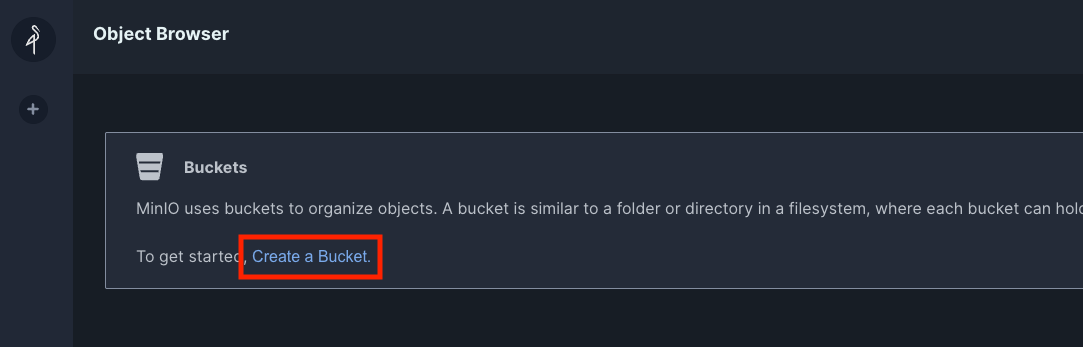

In [5]:
from IPython.display import Image, display
display(Image(filename="/home/iceberg/notebooks/images/minio_create_bucket.png"))

## 테이블 생성하기

In [6]:
# 테이블 생성
spark.sql("""
CREATE TABLE IF NOT EXISTS my_catalog.my_database.my_table (
    id BIGINT,
    name STRING
) USING iceberg
""")

print("아직 테이블에 데이터는 존재하지 않는다.")
# 테이블 데이터 조회
spark.sql("""
SELECT * FROM my_catalog.my_database.my_table
""").show()

아직 테이블에 데이터는 존재하지 않는다.
+---+----+
| id|name|
+---+----+
+---+----+



## 메타데이터 포인터 확인하기
- CREATE TABLE 이후 `s3://warehouse/my_database/my_table/metadata` 경로에 메타데이터 JSON 파일이 생성된 걸 확인할 수 있다.
- REST 카탈로그에서 메타데이터 포인터가 my_table 테이블의 최신 메타데이터 주소를 올바르게 갖고 있는지 확인해보자.

In [7]:
! curl -s http://iceberg-rest:8181/v1/namespaces/my_database/tables/my_table

{"metadata-location":"s3://warehouse/my_database/my_table/metadata/00000-3883e338-c60e-4a73-afa8-91407626509b.metadata.json","metadata":{"format-version":2,"table-uuid":"68ecbca6-8cb8-4e1b-99e2-276255cac5db","location":"s3://warehouse/my_database/my_table","last-sequence-number":0,"last-updated-ms":1759759839326,"last-column-id":2,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"name","required":false,"type":"string"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[]}],"last-partition-id":999,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":-1,"refs":{},"snapshots":[],"statistics":[],"partition-statistics":[],"snapshot-log":[],"metadata-log":[]}}

- 위와 같이 my_table 의 `metadata-location` 정보가 지금 새로 생선된 metadata.json 파일 위치를 잘 가리키고 있다.
- 테이블 변경 사항이 발생할 때마다 새로운 스냅샷을 발행하면서, `metadata.json` 도 새롭게 생성 된다.
  이 때 마다 REST 카탈로그에서 해당 테이블의 metadata-location 정보도 함께 갱신되어 메타데이터 포인터가 항상 최신 메타데이터 주소를 바라보도록 한다.

## metadata.json 파일 살펴보기
- 처음 생성한 테이블의 메타데이터 내용을 살펴본다.

In [13]:
metadata_json = "00000-3883e338-c60e-4a73-afa8-91407626509b.metadata.json"
obj = get_metadata(metadata_json)
metadata_json = json.loads(obj["Body"].read().decode("utf-8"))

for key in IcebergMetadataJsonField:
    print(f"🔑'KEY':{key.value}({FIELD_DESCRIPTIONS[key]})\n ▶︎'VALUE':{metadata_json[key.value]}")
    print("-"*100)

print("\n📋 메타데이터 원본 JSON")
print(json.dumps(metadata_json, indent=2, ensure_ascii=False))

🔑'KEY':format-version(Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/))
 ▶︎'VALUE':2
----------------------------------------------------------------------------------------------------
🔑'KEY':table-uuid(테이블을 고유하게 식별하는 UUID(테이블 변경, 데이터 갱신에도 변경되지 않는 정보))
 ▶︎'VALUE':68ecbca6-8cb8-4e1b-99e2-276255cac5db
----------------------------------------------------------------------------------------------------
🔑'KEY':location(테이블 데이터와 메타데이터가 저장되는 경로)
 ▶︎'VALUE':s3://warehouse/my_database/my_table
----------------------------------------------------------------------------------------------------
🔑'KEY':last-sequence-number(마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 테이블 또는 데이터 갱신 작업마다 늘어남))
 ▶︎'VALUE':0
----------------------------------------------------------------------------------------------------
🔑'KEY':last-updated-ms(메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초))
 ▶︎'VALUE':1759759839326
----------------------------------------------------------------------------------------------------
🔑'KEY':last-column-id(테이블

---

# INSERT
- Iceberg 테이블에 INSERT 후 메타데이터와 데이터 계층의 변화를 살펴본다.
- INSERT 명령 실행 시 내부적으로 일어나는 주요 작업은 다음과 같다:
    - 메타데이터 JSON 파일 갱신 → 새로운 스냅샷 정보가 추가되고, 카탈로그 포인터가 최신 메타데이터를 가리킨다.
    - 매니페스트 리스트 파일 생성/갱신 → 이번 커밋에서 사용된 매니페스트 파일들의 목록을 관리한다.
    - 매니페스트 파일 생성/갱신 → 어떤 데이터파일이 새로 추가되었는지(또는 삭제되었는지) 기록한다.
    - 데이터파일 생성 → 실제 삽입된 데이터가 Parquet/ORC 파일로 저장된다.

## INSERT INTO VALUES
- 멱등성 유지를 위해 id 값이 중복될 경우 삽입 되지 않도록 쿼리만 수정하였다.

In [14]:
spark.sql("""
INSERT INTO my_catalog.my_database.my_table
SELECT id, name
FROM (
  SELECT 1 AS id, 'Alice' AS name
  UNION ALL
  SELECT 2 AS id, 'Bob'   AS name
) tmp
WHERE tmp.id NOT IN (SELECT id FROM my_catalog.my_database.my_table)
""")

print("두 개의 행이 삽입 되었다.")
spark.sql("""
SELECT * FROM my_catalog.my_database.my_table
""").show()

두 개의 행이 삽입 되었다.
+---+-----+
| id| name|
+---+-----+
|  1|Alice|
|  2|  Bob|
+---+-----+



## INSERT 실행 후 메타데이터 포인터(REST 카탈로그)의 메타데이터 경로 확인
- `v1/namespaces/my_database/tables/my_table/` REST API 호출 결과와 같이 my_table 테이블의 `metadata-location` 정보가 갱신 된 것을 확인할 수 있다.
- 즉, 테이블 변경사항이 발생할 때마다 메타데이터 포인터는 최신 metadata.json 파일 경로를 바라보게 된다.
- 이 metadata.json 파일은 Iceberg 아키텍처 그림에서 metadata layer 의 metadata file 에 해당한다.
- 조회 결과중 현재 스냅샷(sequence-number=1)에서 발생했던 **작업(operation) 이 append 인 것을 알 수 있다.(INSERT = APPEND)**

In [35]:
! curl -s http://iceberg-rest:8181/v1/namespaces/my_database/tables/my_table

{"metadata-location":"s3://warehouse/my_database/my_table/metadata/00001-b3eb554c-6d8f-449b-83b1-6f67643d0c39.metadata.json","metadata":{"format-version":2,"table-uuid":"68ecbca6-8cb8-4e1b-99e2-276255cac5db","location":"s3://warehouse/my_database/my_table","last-sequence-number":1,"last-updated-ms":1759759895980,"last-column-id":2,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"name","required":false,"type":"string"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[]}],"last-partition-id":999,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":6905745030424545610,"refs":{"main":{"snapshot-id":6905745030424545610,"type":"branch"}},"snapshots":[{"sequence-number":1,"snapshot-id":6905745030424545610,"timestamp-ms":1759759895980,"summary":{"operation":"append","spark.app.id

## 매니패스트 리스트 파일 내용 확인
- 매니패스트 리스트에서는 INSERT 작업에 대한 커밋에서 사용되는 매니패스트 파일들을 관리한다.
- Iceberg 아키텍처 그림에서 metadata layer 의 manifest list 에 해당한다.

In [34]:
spark.sql("""
SELECT committed_at, snapshot_id, parent_id, operation, manifest_list  FROM my_catalog.my_database.my_table.snapshots
""").show(),
spark.sql("""
SELECT manifest_list  FROM my_catalog.my_database.my_table.snapshots
""").show(truncate=False),

+--------------------+-------------------+---------+---------+--------------------+
|        committed_at|        snapshot_id|parent_id|operation|       manifest_list|
+--------------------+-------------------+---------+---------+--------------------+
|2025-10-06 14:11:...|6905745030424545610|     NULL|   append|s3://warehouse/my...|
+--------------------+-------------------+---------+---------+--------------------+

+-----------------------------------------------------------------------------------------------------------------+
|manifest_list                                                                                                    |
+-----------------------------------------------------------------------------------------------------------------+
|s3://warehouse/my_database/my_table/metadata/snap-6905745030424545610-1-73511a5a-470d-4001-9071-e0d1660a9e9e.avro|
+-----------------------------------------------------------------------------------------------------------------+

(None,)

- 아래 출력 결과와 같이 매니패스트 리스트파일에서 현재 스냅샷에 해당하는 매니패스트 파일들(지금은 1개)의 경로를 관리하고 있다.

In [43]:
manifest_list = "snap-6905745030424545610-1-73511a5a-470d-4001-9071-e0d1660a9e9e.avro"
obj = get_metadata(manifest_list)
bio = io.BytesIO(obj["Body"].read())
avro_rdr = avro_reader(bio)
for manifest in avro_rdr:
    print(manifest)

# print(json.dumps(avro_rdr.writer_schema, indent=2, ensure_ascii=False))

{'manifest_path': 's3://warehouse/my_database/my_table/metadata/73511a5a-470d-4001-9071-e0d1660a9e9e-m0.avro', 'manifest_length': 7046, 'partition_spec_id': 0, 'content': 0, 'sequence_number': 1, 'min_sequence_number': 1, 'added_snapshot_id': 6905745030424545610, 'added_files_count': 2, 'existing_files_count': 0, 'deleted_files_count': 0, 'added_rows_count': 2, 'existing_rows_count': 0, 'deleted_rows_count': 0, 'partitions': [], 'key_metadata': None}


## 매니패스트 파일 내용 확인
- 이번에는 매니패스트 리스트에서 관리되고 있는 매니패스트 파일 내용을 확인해본다.
- 매니패스트 파일에서 데이터 파일들의 위치 정보를 확인할 수 있다.
- 매니패스트 파일은 Iceberg 아키텍처 metadata layer 의 menifest file 에 해당한다.

In [48]:
print("테이블 변경사항이 많아질 수록 매니패스트 파일 수가 증가할 수 있다. 현재는 한 개의 매니패스트 파일이 존재한다.")
spark.sql("""
SELECT path, added_snapshot_id FROM my_catalog.my_database.my_table.manifests
""").show(truncate=False)

테이블 변경사항이 많아질 수록 매니패스트 파일 수가 증가할 수 있다. 현재는 한 개의 매니패스트 파일이 존재한다.
+-----------------------------------------------------------------------------------------+-------------------+
|path                                                                                     |added_snapshot_id  |
+-----------------------------------------------------------------------------------------+-------------------+
|s3://warehouse/my_database/my_table/metadata/73511a5a-470d-4001-9071-e0d1660a9e9e-m0.avro|6905745030424545610|
+-----------------------------------------------------------------------------------------+-------------------+



- 아래 출력 결과와 같이 매니패스트 파일에서 관리중인 데이터 파일 경로를 알 수 있다.
- Iceberg 테이블은 이런식으로 최신 커밋에 대한 실제 데이터 추적을 할 수 있다.
- 이번 실습에서는 (1, 'Alice'), (2, 'Bob') 각 행이 parquet 로 저장되었다.

In [63]:
manifest_file = "73511a5a-470d-4001-9071-e0d1660a9e9e-m0.avro"
obj = get_metadata(manifest_file)
bio = io.BytesIO(obj["Body"].read())
avro_rdr = avro_reader(bio)
for data_file in avro_rdr:
    print(data_file)

{'status': 1, 'snapshot_id': 6905745030424545610, 'sequence_number': None, 'file_sequence_number': None, 'data_file': {'content': 0, 'file_path': 's3://warehouse/my_database/my_table/data/00000-0-3a50395b-48fa-4b73-be78-db9294af1c81-0-00001.parquet', 'file_format': 'PARQUET', 'partition': {}, 'record_count': 1, 'file_size_in_bytes': 693, 'column_sizes': [{'key': 1, 'value': 43}, {'key': 2, 'value': 44}], 'value_counts': [{'key': 1, 'value': 1}, {'key': 2, 'value': 1}], 'null_value_counts': [{'key': 1, 'value': 0}, {'key': 2, 'value': 0}], 'nan_value_counts': [], 'lower_bounds': [{'key': 1, 'value': b'\x01\x00\x00\x00\x00\x00\x00\x00'}, {'key': 2, 'value': b'Alice'}], 'upper_bounds': [{'key': 1, 'value': b'\x01\x00\x00\x00\x00\x00\x00\x00'}, {'key': 2, 'value': b'Alice'}], 'key_metadata': None, 'split_offsets': [4], 'equality_ids': None, 'sort_order_id': 0, 'referenced_data_file': None}}
{'status': 1, 'snapshot_id': 6905745030424545610, 'sequence_number': None, 'file_sequence_number': N

## 데이터 파일 내용 확인
- 데이터 파일에는 parquet, orc 와 같은 확장자에서 실제 데이터가 관리된다. 
- 아래 쿼리 결과와 같이 현재(최신) 스냅샷 시점의 데이터 경로를 조회할 수 있고, 각 데이터 파일에 적재 되어 있는 메트릭을 볼 수 있다.

In [65]:
spark.sql("""
SELECT file_path, record_count, readable_metrics  FROM my_catalog.my_database.my_table.files
""").show(truncate=False)

+-----------------------------------------------------------------------------------------------------+------------+--------------------------------------------------------+
|file_path                                                                                            |record_count|readable_metrics                                        |
+-----------------------------------------------------------------------------------------------------+------------+--------------------------------------------------------+
|s3://warehouse/my_database/my_table/data/00000-0-3a50395b-48fa-4b73-be78-db9294af1c81-0-00001.parquet|1           |{{43, 1, 0, NULL, 1, 1}, {44, 1, 0, NULL, Alice, Alice}}|
|s3://warehouse/my_database/my_table/data/00001-1-3a50395b-48fa-4b73-be78-db9294af1c81-0-00001.parquet|1           |{{43, 1, 0, NULL, 2, 2}, {42, 1, 0, NULL, Bob, Bob}}    |
+-----------------------------------------------------------------------------------------------------+------------+--------------

---

# UPDATE
- Iceberg 테이블에 UPDATE 후 메타데이터와 데이터 계층의 변화를 살펴본다.
- UPDATE 명령 실행 시 내부적으로 일어나는 주요 작업은 다음과 같다:
    - 메타데이터 JSON 파일 갱신 → 새로운 스냅샷이 추가되고, 카탈로그 포인터가 최신 메타데이터를 가리킨다.
    - 매니페스트 리스트 파일 생성/갱신 → 업데이트 작업에서 사용된 매니페스트 파일들의 목록을 관리한다.
    - 매니페스트 파일 생성/갱신 → 어떤 데이터파일이 삭제되고, 어떤 데이터파일이 새로 추가되었는지 기록한다.
    - 데이터파일 생성/삭제 → 기존 데이터가 무효화된(delete) 파일과 새롭게 기록된 데이터 파일이 함께 관리된다.

In [66]:
spark.sql("""
UPDATE my_catalog.my_database.my_table SET name = 'July' WHERE id = 2
""")

DataFrame[]

In [67]:
print("id가 2인 Bob의 이름이 July로 UPDATE 되었다.")
spark.sql("""
SELECT * FROM my_catalog.my_database.my_table
""").show()

+---+-----+
| id| name|
+---+-----+
|  1|Alice|
|  2| July|
+---+-----+



## UPDATE 실행 후 메타데이터 포인터(REST 카탈로그)의 메타데이터 경로 확인
- `v1/namespaces/my_database/tables/my_table/` REST API 호출 결과와 같이 my_table 테이블의 `metadata-location` 정보가 갱신 된 것을 확인할 수 있다.
- 즉, 테이블 변경사항이 발생할 때마다 메타데이터 포인터는 최신 metadata.json 파일 경로를 바라보게 된다.
- 조회 결과중 현재 스냅샷(sequence-number=2)에서 발생했던 **작업(operation) 이 overwrite 인 것을 알 수 있다.(UPDATE = OVERWRITE)**

In [69]:
! curl -s http://iceberg-rest:8181/v1/namespaces/my_database/tables/my_table

{"metadata-location":"s3://warehouse/my_database/my_table/metadata/00002-20079775-b37f-494a-aefd-eb40c4b2ff80.metadata.json","metadata":{"format-version":2,"table-uuid":"68ecbca6-8cb8-4e1b-99e2-276255cac5db","location":"s3://warehouse/my_database/my_table","last-sequence-number":2,"last-updated-ms":1759762021229,"last-column-id":2,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"name","required":false,"type":"string"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[]}],"last-partition-id":999,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":1582859396212041230,"refs":{"main":{"snapshot-id":1582859396212041230,"type":"branch"}},"snapshots":[{"sequence-number":1,"snapshot-id":6905745030424545610,"timestamp-ms":1759759895980,"summary":{"operation":"append","spark.app.id

In [72]:
print("INSERT 다음 UPDATE 완료 되었을 때, 새로운 스냅샷(매니패스트 리스트)이 생성 된 것을 확인할 수 있다.")
print("그리고 UPDATE 에 해당하는 스냅샷은 이전 INSERT 작업에 해당하는 스냅샷을 parent_id 로 갖고 있다.")
spark.sql("""
SELECT committed_at, snapshot_id, parent_id, operation, manifest_list  FROM my_catalog.my_database.my_table.snapshots
""").show(),
print("INSERT 작업 때와 달리 UPDATE 후 매니패스트 리스트 파일이 늘어난 것을 볼 수 있다.")
spark.sql("""
SELECT manifest_list  FROM my_catalog.my_database.my_table.snapshots
""").show(truncate=False),

INSERT 다음 UPDATE 완료 되었을 때, 새로운 스냅샷(매니패스트 리스트)이 생성 된 것을 확인할 수 있다.
그리고 UPDATE 에 해당하는 스냅샷은 이전 INSERT 작업에 해당하는 스냅샷을 parent_id 로 갖고 있다.
+--------------------+-------------------+-------------------+---------+--------------------+
|        committed_at|        snapshot_id|          parent_id|operation|       manifest_list|
+--------------------+-------------------+-------------------+---------+--------------------+
|2025-10-06 14:11:...|6905745030424545610|               NULL|   append|s3://warehouse/my...|
|2025-10-06 14:47:...|1582859396212041230|6905745030424545610|overwrite|s3://warehouse/my...|
+--------------------+-------------------+-------------------+---------+--------------------+

INSERT 작업 때와 달리 UPDATE 후 매니패스트 리스트 파일이 늘어난 것을 볼 수 있다.
+-----------------------------------------------------------------------------------------------------------------+
|manifest_list                                                                                                    |
+-----------------

(None,)